# Breadth-First and Depth-First Search

This notebook compares BFS and DFS on the same grid world. Both algorithms explore reachable states, but the data structure used for the frontier changes the order of exploration and the path that is returned.

## Notebook overview

Run the cells from top to bottom. The notebook has four parts:

1. Build and display a connected grid map.
2. Explore it with breadth-first search.
3. Explore it with iterative depth-first search.
4. Express depth-first search recursively.

## Visual legend

- **Gray:** wall
- **White:** open state
- **Green:** start
- **Red:** goal
- **Yellow:** visited state
- **Cyan:** state currently being expanded

All three searches use the same map, start state, goal state, neighbor order, and drawing helpers. This makes their exploration patterns directly comparable.

## Imports and shared constants

NumPy stores the grid and visited arrays. Matplotlib draws the map and the intermediate search states. A wall is represented by `"#"`; an open cell is represented by `"."`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

WALL = "#"
EMPTY = "."

figure_size = 1.5



## Generate a connected map

`generate_map` first samples walls and open cells, then removes one wall from any completely blocked 2-by-2 region. It next uses **union-find**, also called the **disjoint-set data structure**, to track which open cells belong to the same connected component.

- `find(x)` follows parent links to obtain a component representative and shortens future searches with path compression.
- `union(x, y)` joins the components containing two neighboring open cells.
- A wall is removed when its open neighbors belong to different components, allowing those components to be connected.

For a visual introduction to the data structure, see Princeton Algorithms' [Union-Find case study](https://algs4.cs.princeton.edu/15uf/).

In [ ]:
def generate_map(width, height, seed):
    np.random.seed(seed)
    m = np.random.choice([WALL, EMPTY], size=(height, width))
    # scan all 2x2 blocks and remove walls that are not needed
    for i in range(height - 1):
        for j in range(width - 1):
            block = m[i : i + 2, j : j + 2]
            if np.sum(block == WALL) == 4:
                # randomly remove one wall
                block[np.random.randint(2), np.random.randint(2)] = EMPTY
    # run union-find to make sure the map is connected
    parent = np.arange(width * height)

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return parent[x]

    def union(x, y):
        parent[find(x)] = find(y)

    for i in range(height):
        for j in range(width):
            if m[i, j] == WALL:
                continue
            for ni, nj in [(i + 1, j), (i, j + 1)]:
                if ni < height and nj < width and m[ni, nj] == EMPTY:
                    union(i * width + j, ni * width + nj)
    for i in range(height):
        for j in range(width):
            if m[i, j] == WALL:
                # check if all neighbors of this wall are connected
                # if not, remove this wall
                neighbors = []
                for ni, nj in [(i + 1, j), (i - 1, j), (i, j + 1), (i, j - 1)]:
                    if 0 <= ni < height and 0 <= nj < width and m[ni, nj] == EMPTY:
                        neighbors.append(
                            find(ni * width + nj)
                        )  # get the parent of all empty neighbors
                if len(neighbors) != 0 and len(set(neighbors)) != 1:
                    m[i, j] = EMPTY
                    # connect all neighbors
                    for k in range(1, len(neighbors)):
                        union(neighbors[k - 1], neighbors[k])
    return m




## Choose the start and goal

`find_start_end` repeatedly samples two grid coordinates until both are open cells. The same `start` and `end` values are reused by every search algorithm below.

In [ ]:
def find_start_end(m):
    # randomly find a start and end point
    h, w = m.shape
    start = np.random.randint(h), np.random.randint(w)
    end = np.random.randint(h), np.random.randint(w)
    while m[start] == WALL or m[end] == WALL:
        start = np.random.randint(h), np.random.randint(w)
        end = np.random.randint(h), np.random.randint(w)
    return start, end




## Draw the grid

`show_map` draws one rectangle per cell, adds row and column indices, preserves square cells with an equal aspect ratio, and hides the ordinary plot axes.

In [ ]:
def show_map(m, ax=None):
    h, w = m.shape
    for i in range(h):
        for j in range(w):
            # draw a rectangle
            ax.add_patch(
                plt.Rectangle(
                    (j, h - i - 1), 1, 1, fc="gray" if m[i, j] == WALL else "white"
                )
            )
            # draw the border
            ax.add_patch(
                plt.Rectangle((j, h - i - 1), 1, 1, fill=False, edgecolor="black")
            )
    # draw indices of horizontal and vertical axis
    for i in range(h):
        ax.text(-0.5, h - i - 0.5, str(i), ha="center", va="center")
    for j in range(w):
        ax.text(j + 0.5, h + 0.5, str(j), ha="center", va="center")
    ax.set_xlim(-0.3, w + 0.3)
    ax.set_ylim(-0.3, h + 0.3)
    ax.set_aspect("equal", adjustable="box")
    ax.axis("off")




## Draw a returned path

`draw_path` first draws the grid, colors the two endpoints, and then connects consecutive coordinates in `path`. It expects the path to be ordered from the start state to the goal state.

In [ ]:
def draw_path(m, path, ax):
    h, w = m.shape
    last = path[0]
    show_map(m, ax)
    # draw the start and end points by filling the grid with a different color
    ax.add_patch(plt.Rectangle((last[1], h - last[0] - 1), 1, 1, fc="green"))
    ax.add_patch(plt.Rectangle((path[-1][1], h - path[-1][0] - 1), 1, 1, fc="red"))
    for i, j in path[1:]:
        # connect the two points
        ax.plot([last[1] + 0.5, j + 0.5], [h - last[0] - 0.5, h - i - 0.5], "r", lw=2)
        last = (i, j)




## Build the example problem

The fixed random seed makes the map reproducible. The saved figure below shows the exact problem used by BFS and both DFS implementations.

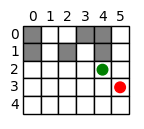

In [97]:
# a = generate_map(5, 3, 1)
a = generate_map(6, 5, 2)
start, end = find_start_end(a)
# create a figure
fig, ax = plt.subplots(figsize=(figure_size, figure_size))
show_map(a, ax)
# plot the start and end points
ax.add_patch(
    plt.Circle((start[1] + 0.5, a.shape[0] - start[0] - 0.5), 0.3, color="green")
)
ax.add_patch(plt.Circle((end[1] + 0.5, a.shape[0] - end[0] - 0.5), 0.3, color="red"))
plt.show()

## Breadth-First Search

BFS expands states in increasing depth order. Because every grid move has the same cost, the first path it finds to the goal has the fewest moves.

The function has four stages:

1. Initialize the queue with the start state and mark it visited.
2. Remove the oldest queued state with `pop(0)`.
3. Add each valid, unvisited neighbor and record its parent.
4. Follow parent links backward from the goal, then reverse the list.

The state is marked visited when it is added to the queue. This prevents the same state from being queued by multiple parents. A Python list is clear for this small demonstration; `collections.deque` gives efficient removal from the left for larger problems.

In [ ]:
# BFS to find the shortest path
def bfs(m, start, end):
    h, w = m.shape
    q = [start]
    visited = np.zeros((h, w), dtype=bool)
    visited[start[0], start[1]] = True
    parent = np.zeros((h, w, 2), dtype=int)

    print("queue:", q)

    while q:
        i, j = q.pop(0)

        print("current position:", (i, j))
        print("queue:", q)
        fig, ax = plt.subplots(figsize=(figure_size, figure_size))
        show_map(m, ax)
        # paint the visited grid with a different color
        for ii in range(h):
            for jj in range(w):
                if visited[ii, jj]:
                    ax.add_patch(
                        plt.Rectangle((jj, h - ii - 1), 1, 1, fc="yellow", alpha=0.5)
                    )
        ax.add_patch(plt.Rectangle((j + 0.1, h - i - 0.9), 0.8, 0.8, fc="cyan"))
        plt.show()

        if (i, j) == end:
            break
        for ni, nj in [(i + 1, j), (i - 1, j), (i, j + 1), (i, j - 1)]:
            if (
                0 <= ni < h
                and 0 <= nj < w
                and not visited[ni, nj]
                and m[ni, nj] == EMPTY
            ):
                visited[ni, nj] = True
                parent[ni, nj] = (i, j)
                q.append((ni, nj))
        print("queue:", q)
    path = []
    i, j = end
    while (i, j) != start:
        path.append((i, j))
        i, j = parent[i, j]
    path.append(start)
    return path[::-1]




### Run BFS

The printed queue reveals FIFO order. In each saved figure, yellow cells have been discovered and the cyan cell is the state currently being expanded. The final figure draws the returned shortest path.

queue: [(2, 4)]
current position: (2, 4)
queue: []


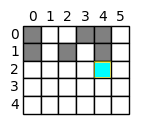

queue: [(3, 4), (2, 5), (2, 3)]
current position: (3, 4)
queue: [(2, 5), (2, 3)]


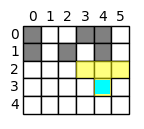

queue: [(2, 5), (2, 3), (4, 4), (3, 5), (3, 3)]
current position: (2, 5)
queue: [(2, 3), (4, 4), (3, 5), (3, 3)]


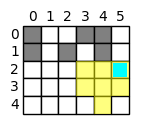

queue: [(2, 3), (4, 4), (3, 5), (3, 3), (1, 5)]
current position: (2, 3)
queue: [(4, 4), (3, 5), (3, 3), (1, 5)]


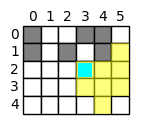

queue: [(4, 4), (3, 5), (3, 3), (1, 5), (1, 3), (2, 2)]
current position: (4, 4)
queue: [(3, 5), (3, 3), (1, 5), (1, 3), (2, 2)]


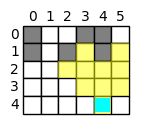

queue: [(3, 5), (3, 3), (1, 5), (1, 3), (2, 2), (4, 5), (4, 3)]
current position: (3, 5)
queue: [(3, 3), (1, 5), (1, 3), (2, 2), (4, 5), (4, 3)]


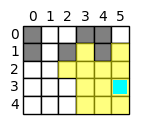

[(2, 4), (3, 4), (3, 5)]


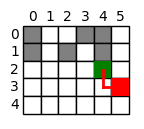

In [98]:
path = bfs(a, start, end)
print(path)


fig, ax = plt.subplots(figsize=(figure_size, figure_size))
draw_path(a, path, ax)
plt.show()

## Iterative Depth-First Search

Iterative DFS follows one branch deeply before backtracking. Its structure closely matches BFS, but the frontier is a stack:

- `append` pushes a state onto the stack.
- `pop()` removes the newest state.
- The parent array records how the returned path was reached.

Neighbor order matters because the last neighbor pushed is the first one expanded. DFS may reach the goal quickly, but the first path it finds is not guaranteed to be shortest. Its frontier can be smaller than BFS's frontier, although the visited and parent arrays still require space proportional to the grid.

In [ ]:
def dfs_iterative(m, start, end):
    h, w = m.shape
    s = [start]
    visited = np.zeros((h, w), dtype=bool)
    visited[start[0], start[1]] = True
    parent = np.zeros((h, w, 2), dtype=int)

    print("stack:", s)

    while s:
        i, j = s.pop()

        print("current position:", (i, j))
        print("stack:", s)
        fig, ax = plt.subplots(figsize=(figure_size, figure_size))
        show_map(m, ax)
        # paint the visited grid with a different color
        for ii in range(h):
            for jj in range(w):
                if visited[ii, jj]:
                    ax.add_patch(
                        plt.Rectangle((jj, h - ii - 1), 1, 1, fc="yellow", alpha=0.5)
                    )
        ax.add_patch(plt.Rectangle((j + 0.1, h - i - 0.9), 0.8, 0.8, fc="cyan"))
        plt.show()

        if (i, j) == end:
            break
        for ni, nj in [(i + 1, j), (i - 1, j), (i, j + 1), (i, j - 1)]:
            if (
                0 <= ni < h
                and 0 <= nj < w
                and not visited[ni, nj]
                and m[ni, nj] == EMPTY
            ):
                visited[ni, nj] = True
                parent[ni, nj] = (i, j)
                s.append((ni, nj))
        print("stack:", s)
    path = []
    i, j = end
    while (i, j) != start:
        path.append((i, j))
        i, j = parent[i, j]
    path.append(start)
    return path[::-1]




### Run iterative DFS

Compare the printed stack and yellow exploration region with the BFS output. The map and endpoints are unchanged, so the difference comes from LIFO rather than FIFO frontier order.

stack: [(2, 4)]
current position: (2, 4)
stack: []


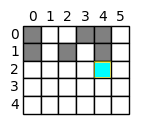

stack: [(3, 4), (2, 5), (2, 3)]
current position: (2, 3)
stack: [(3, 4), (2, 5)]


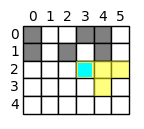

stack: [(3, 4), (2, 5), (3, 3), (1, 3), (2, 2)]
current position: (2, 2)
stack: [(3, 4), (2, 5), (3, 3), (1, 3)]


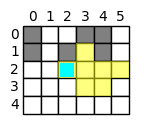

stack: [(3, 4), (2, 5), (3, 3), (1, 3), (3, 2), (2, 1)]
current position: (2, 1)
stack: [(3, 4), (2, 5), (3, 3), (1, 3), (3, 2)]


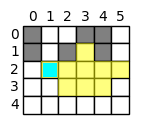

stack: [(3, 4), (2, 5), (3, 3), (1, 3), (3, 2), (3, 1), (1, 1), (2, 0)]
current position: (2, 0)
stack: [(3, 4), (2, 5), (3, 3), (1, 3), (3, 2), (3, 1), (1, 1)]


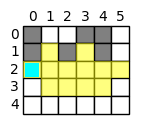

stack: [(3, 4), (2, 5), (3, 3), (1, 3), (3, 2), (3, 1), (1, 1), (3, 0)]
current position: (3, 0)
stack: [(3, 4), (2, 5), (3, 3), (1, 3), (3, 2), (3, 1), (1, 1)]


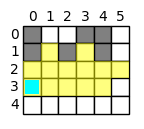

stack: [(3, 4), (2, 5), (3, 3), (1, 3), (3, 2), (3, 1), (1, 1), (4, 0)]
current position: (4, 0)
stack: [(3, 4), (2, 5), (3, 3), (1, 3), (3, 2), (3, 1), (1, 1)]


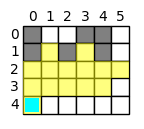

stack: [(3, 4), (2, 5), (3, 3), (1, 3), (3, 2), (3, 1), (1, 1), (4, 1)]
current position: (4, 1)
stack: [(3, 4), (2, 5), (3, 3), (1, 3), (3, 2), (3, 1), (1, 1)]


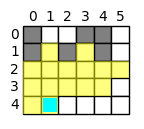

stack: [(3, 4), (2, 5), (3, 3), (1, 3), (3, 2), (3, 1), (1, 1), (4, 2)]
current position: (4, 2)
stack: [(3, 4), (2, 5), (3, 3), (1, 3), (3, 2), (3, 1), (1, 1)]


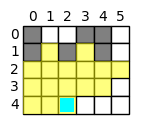

stack: [(3, 4), (2, 5), (3, 3), (1, 3), (3, 2), (3, 1), (1, 1), (4, 3)]
current position: (4, 3)
stack: [(3, 4), (2, 5), (3, 3), (1, 3), (3, 2), (3, 1), (1, 1)]


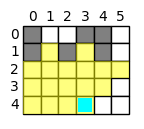

stack: [(3, 4), (2, 5), (3, 3), (1, 3), (3, 2), (3, 1), (1, 1), (4, 4)]
current position: (4, 4)
stack: [(3, 4), (2, 5), (3, 3), (1, 3), (3, 2), (3, 1), (1, 1)]


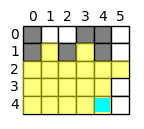

stack: [(3, 4), (2, 5), (3, 3), (1, 3), (3, 2), (3, 1), (1, 1), (4, 5)]
current position: (4, 5)
stack: [(3, 4), (2, 5), (3, 3), (1, 3), (3, 2), (3, 1), (1, 1)]


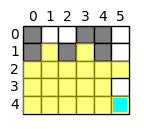

stack: [(3, 4), (2, 5), (3, 3), (1, 3), (3, 2), (3, 1), (1, 1), (3, 5)]
current position: (3, 5)
stack: [(3, 4), (2, 5), (3, 3), (1, 3), (3, 2), (3, 1), (1, 1)]


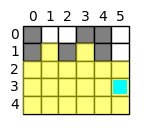

[(2, 4), (2, 3), (2, 2), (2, 1), (2, 0), (3, 0), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (3, 5)]


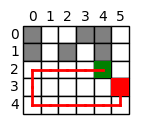

In [99]:
path = dfs_iterative(a, start, end)
print(path)
fig, ax = plt.subplots(figsize=(figure_size, figure_size))
draw_path(a, path, ax)
plt.show()

## Recursive Depth-First Search

The recursive version stores the frontier implicitly in Python's call stack. Each call explores one position and recursively tries its valid neighbors.

- The base case returns a one-state path at the goal.
- A successful recursive call prepends the current state as the calls unwind.
- An empty list signals that a branch did not reach the goal.

Because the path is assembled while recursion unwinds, check its direction before applying another reversal. Deep searches can also reach Python's recursion limit, so iterative DFS is more robust on large state spaces.

In [ ]:
# dfs with recursion
def dfs_recursive(m, start, end):
    h, w = m.shape
    visited = np.zeros((h, w), dtype=bool)
    visited[start[0], start[1]] = True
    parent = np.zeros((h, w, 2), dtype=int)

    def dfs(i, j):
        print("current position:", (i, j))
        fig, ax = plt.subplots(figsize=(figure_size, figure_size))
        show_map(m, ax)
        # paint the visited grid with a different color
        for ii in range(h):
            for jj in range(w):
                if visited[ii, jj]:
                    ax.add_patch(
                        plt.Rectangle((jj, h - ii - 1), 1, 1, fc="yellow", alpha=0.5)
                    )
        ax.add_patch(plt.Rectangle((j + 0.1, h - i - 0.9), 0.8, 0.8, fc="cyan"))
        plt.show()

        if (i, j) == end:
            return [(i, j)]
        for ni, nj in [(i + 1, j), (i - 1, j), (i, j + 1), (i, j - 1)]:
            if (
                0 <= ni < h
                and 0 <= nj < w
                and not visited[ni, nj]
                and m[ni, nj] == EMPTY
            ):
                visited[ni, nj] = True
                parent[ni, nj] = (i, j)
                path = dfs(ni, nj)
                if path:
                    return [(i, j)] + path
        return []

    path = dfs(start[0], start[1])
    return path[::-1]



### Run recursive DFS

Inspect the printed path before interpreting the final drawing. If the first coordinate is the goal instead of the start, the outer reversal has reversed a path that was already assembled in start-to-goal order.

current position: (2, 4)


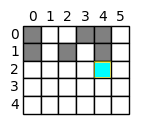

current position: (3, 4)


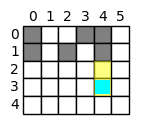

current position: (4, 4)


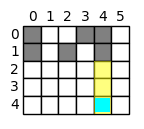

current position: (4, 5)


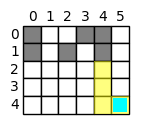

current position: (3, 5)


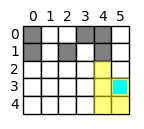

[(3, 5), (4, 5), (4, 4), (3, 4), (2, 4)]


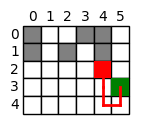

In [100]:
path = dfs_recursive(a, start, end)
print(path)
fig, ax = plt.subplots(figsize=(figure_size, figure_size))
draw_path(a, path, ax)
plt.show()


## Comparison and discussion

| Question | BFS | Iterative DFS | Recursive DFS |
|---|---|---|---|
| Frontier discipline | FIFO queue | LIFO stack | Python call stack |
| Shortest path with equal step costs? | Yes | No | No |
| Sensitive to neighbor order? | Yes | Yes | Yes |
| Main depth risk | Broad frontier | Deep branch | Deep branch and recursion limit |

## Check your understanding

1. Why does marking a state visited when it enters the frontier avoid duplicate work?
2. Which single line changes FIFO behavior into LIFO behavior?
3. Why can two correct DFS implementations return different paths?
4. What happens if a goal is unreachable and path reconstruction assumes it was found?
5. How would a `deque` change the BFS implementation without changing the algorithm?

<details class="notebook-answers">
<summary>Answers and discussion</summary>

1. **Mark on discovery.** Once a state is marked, another parent cannot add it again. Each reachable state enters the frontier at most once, avoiding repeated expansion and conflicting parent assignments. This is appropriate for this unweighted BFS/DFS example; weighted shortest-path search needs different cost bookkeeping.
2. **Change which end is removed.** Replacing `i, j = q.pop(0)` with `i, j = q.pop()` changes the same list from FIFO to LIFO. The iterative DFS code calls its list `s`, but the name is not what changes the behavior.
3. **DFS depends on traversal order.** Recursive DFS immediately follows the first eligible neighbor, whereas pushing neighbors onto a stack makes the last pushed neighbor run first. Different ordering or discovery timing can produce different parent trees and valid paths. Neither version promises a shortest path.
4. **Reconstruction can fail or never terminate.** Here the unused parent entries contain `(0, 0)`. Starting from an unreachable goal can follow those defaults, produce an invalid path, or loop at `(0, 0)`. Check that the goal was reached and return `None` or an empty path before reconstructing; the drawing helper must also handle failure.
5. **Use efficient queue removal.** Import `deque`, initialize `q = deque([start])`, and replace `q.pop(0)` with `q.popleft()`. Keep `append` for insertion. FIFO order and the returned shortest-path length stay the same, while removal avoids shifting all remaining list elements.

</details>

## Summary

BFS and DFS share most of their machinery. The frontier discipline controls exploration order, completeness behavior, memory use, and whether the first discovered path is guaranteed to be shortest.